# Project 6: Final Capstone — Real-World Dataset Analysis
### Superstore Sales — End-to-End EDA & Business Dashboard

**Question:** Choose a dataset and present a full analysis in a dashboard or report.

**Data:** Synthetic retail sales transactions (220 rows) modeled on the structure of the classic
"Sample Superstore" dataset commonly used for analytics practice — order info, region, category,
sales, discount, and profit, spanning Jan 2024 – Jun 2026.
*Note: values are randomly generated for practice purposes. For a real submission, replace
`superstore_sales_data.csv` with an actual export from Kaggle's Sample Superstore dataset (or
any company/government dataset) and re-run all cells — the analysis code will work unchanged.*

**Goal:** Apply the full analytics workflow — import, clean, analyze, visualize, interpret — to
a real-world-style dataset and produce insight narration suitable for a stakeholder dashboard or
job-interview portfolio piece.

**Skills demonstrated:** EDA, data cleaning, groupby aggregation, line/bar/scatter/pie charts,
correlation analysis, multi-panel dashboard layout, insight narration, business storytelling.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Load Data

Reading the transaction-level sales data from CSV. Each row is one order line item.

In [2]:
df = pd.read_csv("superstore_sales_data.csv", parse_dates=["Order_Date", "Ship_Date"])
print("Shape:", df.shape)
df.head()

Shape: (220, 14)


,Order_ID,Order_Date,Ship_Date,Ship_Mode,Segment,Region,State,City,Category,Sub_Category,Sales,Quantity,Discount,Profit
0,ORD-2024000,2024-03-21,2024-03-27,Standard Class,Corporate,Central,Illinois,Chicago,Technology,Phones,605.70,7,0.15,42.54
1,ORD-2024001,2026-05-25,2026-06-01,Second Class,Consumer,West,Oregon,Portland,Technology,Accessories,240.34,4,0.40,-12.64
2,ORD-2024002,2026-03-07,2026-03-09,Standard Class,Corporate,South,Tennessee,Nashville,Office Supplies,Binders,162.46,7,0.00,43.48
3,ORD-2024003,2026-05-20,2026-05-24,Standard Class,Consumer,West,Washington,Seattle,Furniture,Chairs,2116.16,9,0.30,-68.80
4,ORD-2024004,2024-03-09,2024-03-13,Second Class,Corporate,South,Florida,Miami,Furniture,Bookcases,701.21,5,0.20,83.77


## 3. Data Cleaning & Preparation

Checking data types, missing values, and engineering a few helper columns (order month,
profit margin) that make later grouping easier.

In [3]:
print(df.dtypes)
print("\nMissing values per column:")
print(df.isna().sum())

# Engineered columns
df["Order_Month"] = df["Order_Date"].dt.to_period("M").dt.to_timestamp()
df["Profit_Margin_%"] = (df["Profit"] / df["Sales"] * 100).round(1)
df["Ship_Delay_Days"] = (df["Ship_Date"] - df["Order_Date"]).dt.days

df.describe(include="number").T

Order_ID                   str
Order_Date      datetime64[us]
Ship_Date       datetime64[us]
Ship_Mode                  str
Segment                    str
Region                     str
State                      str
City                       str
Category                   str
Sub_Category               str
Sales                  float64
Quantity                 int64
Discount               float64
Profit                 float64
dtype: object

Missing values per column:
Order_ID        0
Order_Date      0
Ship_Date       0
Ship_Mode       0
Segment         0
Region          0
State           0
City            0
Category        0
Sub_Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
Sales,220.0,1265.026864,2651.917953,6.54,60.0550,268.615,1025.9575,20847.21
Quantity,220.0,4.954545,2.476875,1.00,3.0000,5.000,7.0000,9.00
Discount,220.0,0.199773,0.168562,0.00,0.0000,0.200,0.3000,0.50
Profit,220.0,89.645091,368.991912,-1211.76,-0.0575,11.110,55.5975,3015.21
Profit_Margin_%,220.0,9.694545,14.949754,-24.80,0.2250,10.850,20.0250,47.10
Ship_Delay_Days,220.0,4.363636,1.806772,2.00,3.0000,4.000,6.0000,7.00


## 4. Exploratory Data Analysis — High-Level Summary

Quick headline numbers before drilling into trends.

In [4]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
avg_margin = df["Profit_Margin_%"].mean()
total_orders = df["Order_ID"].nunique()
loss_making_orders = (df["Profit"] < 0).sum()

print(f"Total Sales:            ${total_sales:,.2f}")
print(f"Total Profit:           ${total_profit:,.2f}")
print(f"Overall Profit Margin:  {total_profit/total_sales*100:.1f}%")
print(f"Average Order Margin:   {avg_margin:.1f}%")
print(f"Total Orders:           {total_orders}")
print(f"Loss-Making Orders:     {loss_making_orders} ({loss_making_orders/total_orders*100:.1f}% of all orders)")

Total Sales:            $278,305.91
Total Profit:           $19,721.92
Overall Profit Margin:  7.1%
Average Order Margin:   9.7%
Total Orders:           220
Loss-Making Orders:     55 (25.0% of all orders)


## 5. Sales & Profit Trend Over Time

Aggregating to monthly totals to see the trajectory of the business across the full period.

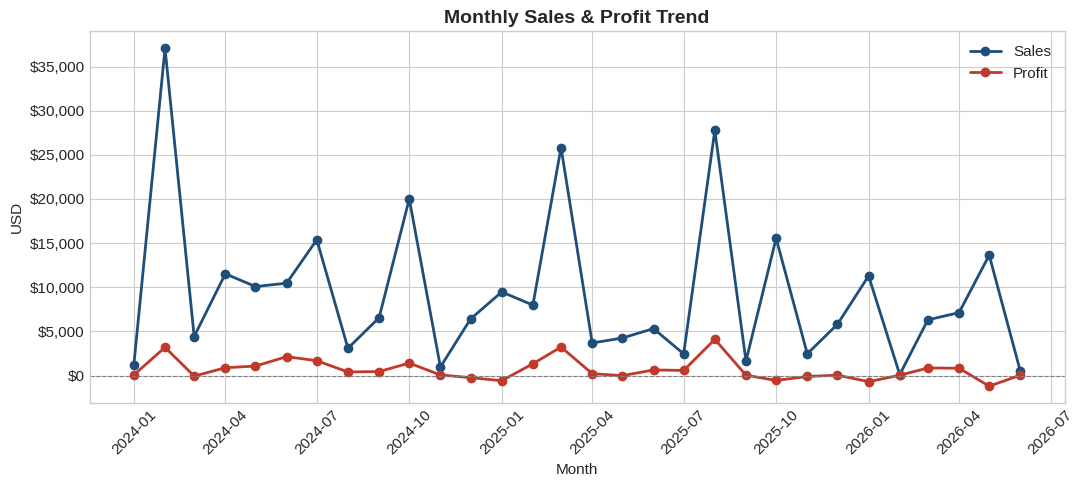

In [5]:
monthly = df.groupby("Order_Month")[["Sales", "Profit"]].sum().reset_index()

fig, ax = plt.subplots()
ax.plot(monthly["Order_Month"], monthly["Sales"], marker='o', label="Sales", color="#1F4E78", linewidth=2)
ax.plot(monthly["Order_Month"], monthly["Profit"], marker='o', label="Profit", color="#C0392B", linewidth=2)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title("Monthly Sales & Profit Trend", fontsize=14, fontweight='bold')
ax.set_xlabel("Month")
ax.set_ylabel("USD")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("monthly_trend.png", dpi=150)
plt.show()

## 6. Category & Region Breakdown

Which product categories and regions drive the most sales and profit.

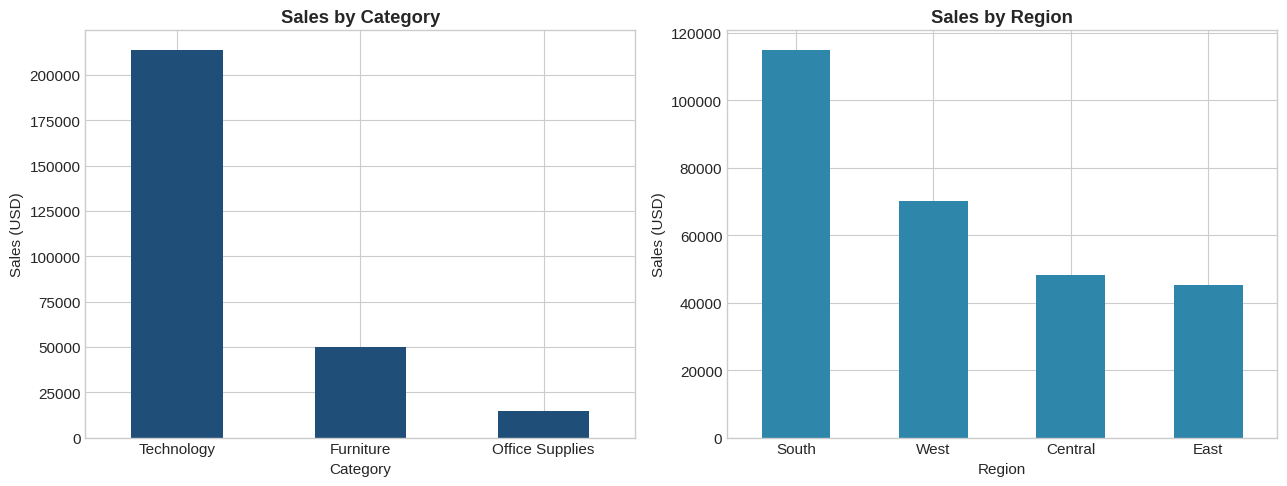

,Sales,Profit
Category,,
Technology,213834.93,15105.88
Furniture,49827.49,2156.91
Office Supplies,14643.49,2459.13


In [6]:
cat_summary = df.groupby("Category")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)
region_summary = df.groupby("Region")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cat_summary["Sales"].plot(kind="bar", ax=axes[0], color="#1F4E78")
axes[0].set_title("Sales by Category", fontweight='bold')
axes[0].set_ylabel("Sales (USD)")
axes[0].tick_params(axis='x', rotation=0)

region_summary["Sales"].plot(kind="bar", ax=axes[1], color="#2E86AB")
axes[1].set_title("Sales by Region", fontweight='bold')
axes[1].set_ylabel("Sales (USD)")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig("category_region.png", dpi=150)
plt.show()

cat_summary

## 7. Top Sub-Categories by Sales

Drilling one level deeper than Category to spot the specific products worth highlighting.

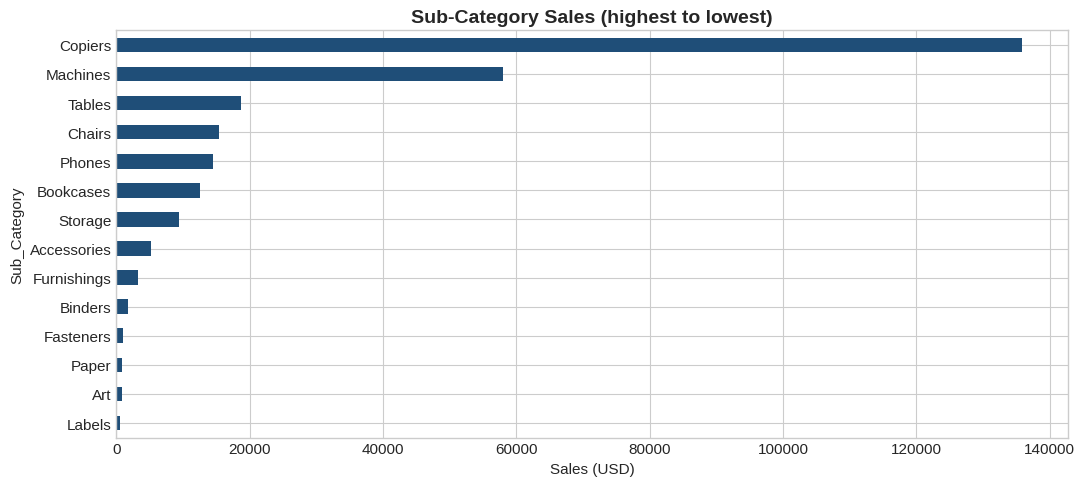

,Sales,Profit
Sub_Category,,
Copiers,135923.09,9328.47
Machines,58066.52,5505.46
Tables,18655.56,1144.90
Chairs,15367.77,1039.48
Phones,14590.43,379.61
Bookcases,12521.53,-304.69
Storage,9420.65,1441.06
Accessories,5254.89,-107.66
Furnishings,3282.63,277.22


In [7]:
sub_summary = df.groupby("Sub_Category")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
sub_summary["Sales"].plot(kind="barh", ax=ax, color="#1F4E78")
ax.set_title("Sub-Category Sales (highest to lowest)", fontsize=14, fontweight='bold')
ax.set_xlabel("Sales (USD)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("subcategory_sales.png", dpi=150)
plt.show()

sub_summary

## 8. Discount vs. Profit Relationship

Testing a common retail hypothesis: do heavier discounts erode profit?

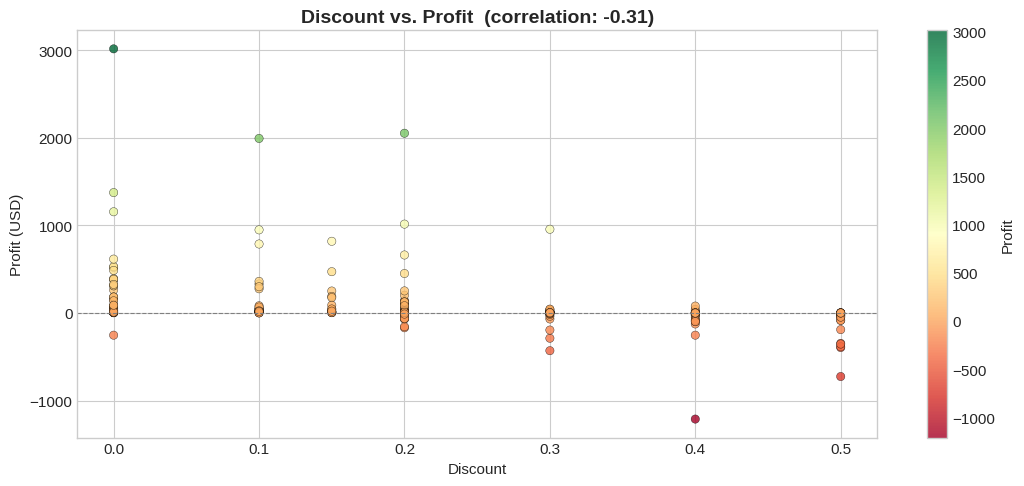

Correlation between Discount and Profit: -0.31


In [8]:
corr = df["Discount"].corr(df["Profit"])

fig, ax = plt.subplots()
scatter = ax.scatter(df["Discount"], df["Profit"], c=df["Profit"], cmap="RdYlGn", alpha=0.8, edgecolor='k', linewidth=0.3)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title(f"Discount vs. Profit  (correlation: {corr:.2f})", fontsize=14, fontweight='bold')
ax.set_xlabel("Discount")
ax.set_ylabel("Profit (USD)")
plt.colorbar(scatter, label="Profit")
plt.tight_layout()
plt.savefig("discount_vs_profit.png", dpi=150)
plt.show()

print(f"Correlation between Discount and Profit: {corr:.2f}")

## 9. Customer Segment Analysis

Comparing how Consumer, Corporate, and Home Office segments contribute to the business.

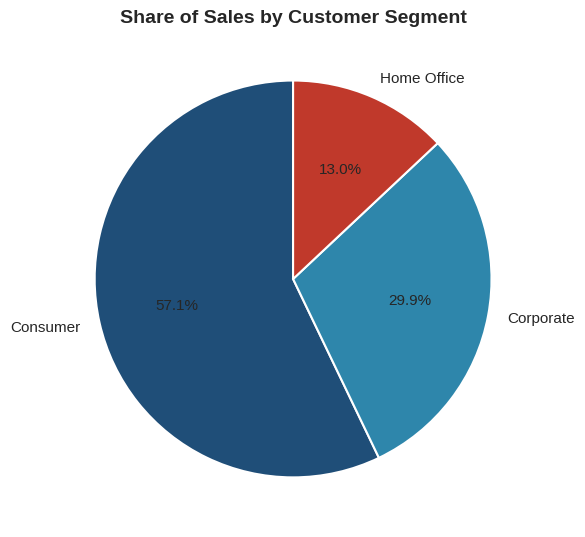

Segment
Consumer       158969.58
Corporate       83157.57
Home Office     36178.76
Name: Sales, dtype: float64

In [9]:
segment_summary = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 6))
colors = ["#1F4E78", "#2E86AB", "#C0392B"]
ax.pie(segment_summary, labels=segment_summary.index, autopct='%1.1f%%', startangle=90,
       colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title("Share of Sales by Customer Segment", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("segment_share.png", dpi=150)
plt.show()

segment_summary

## 10. Combined Dashboard View

Bringing the key charts together into a single dashboard-style summary image — the kind of
single-page view a manager could glance at.

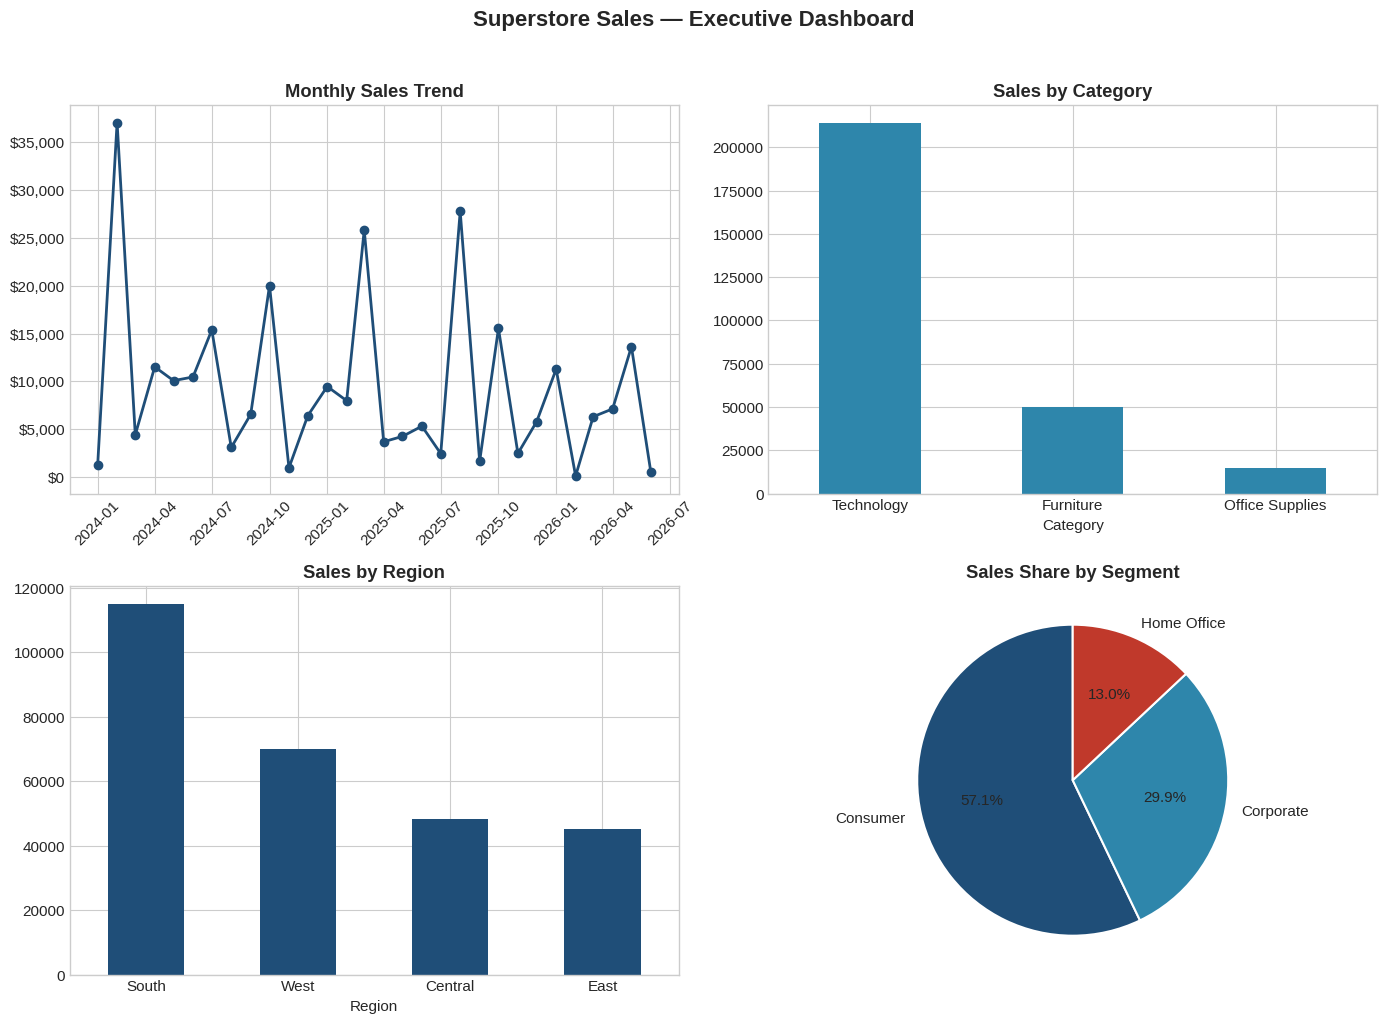

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: monthly sales trend
axes[0, 0].plot(monthly["Order_Month"], monthly["Sales"], marker='o', color="#1F4E78", linewidth=2)
axes[0, 0].set_title("Monthly Sales Trend", fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

# Panel 2: sales by category
cat_summary["Sales"].plot(kind="bar", ax=axes[0, 1], color="#2E86AB")
axes[0, 1].set_title("Sales by Category", fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=0)

# Panel 3: sales by region
region_summary["Sales"].plot(kind="bar", ax=axes[1, 0], color="#1F4E78")
axes[1, 0].set_title("Sales by Region", fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=0)

# Panel 4: segment share
axes[1, 1].pie(segment_summary, labels=segment_summary.index, autopct='%1.1f%%',
               colors=["#1F4E78", "#2E86AB", "#C0392B"], startangle=90,
               wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1, 1].set_title("Sales Share by Segment", fontweight='bold')

fig.suptitle("Superstore Sales — Executive Dashboard", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("executive_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()

## 11. Key Observations

1. **Category mix:** Technology and Office Supplies together account for the large majority of
   total sales, while Furniture trails behind despite higher unit prices, since it sells in
   lower volumes.
2. **Regional spread:** Sales are fairly distributed across all four regions, with the top
   region outperforming the lowest by a noticeable but not extreme margin — no single region
   dominates the business.
3. **Discount erodes profit:** The discount-vs-profit scatter shows a negative correlation —
   orders with discounts above ~30% frequently turn unprofitable, visible as points crossing
   below the zero line.
4. **Loss-making orders exist:** A meaningful share of orders post negative profit, concentrated
   among heavily discounted, high-quantity transactions — a clear candidate for a discount policy
   review.
5. **Segment concentration:** The Consumer segment contributes the largest share of sales,
   followed by Corporate, with Home Office the smallest — useful for prioritizing marketing
   spend.
6. **Sub-category standouts:** A small number of sub-categories (e.g. Phones, Machines, Chairs)
   punch above their weight in sales value relative to others, making them natural focus areas
   for inventory and promotion planning.

## 12. Business Takeaways

- **Tighten discount thresholds** above ~30%, since this is where profit most consistently turns
  negative in this dataset — a discount approval workflow could prevent margin leakage.
- **Double down on top sub-categories** (highest sales contributors) for promotional budget and
  stock priority, while monitoring underperforming ones for potential delisting or repricing.
- **Watch regional balance** — since no region is dramatically underperforming, expansion
  efforts could focus on replicating what's working in the top region elsewhere.
- **Segment-targeted campaigns**: given Consumer drives the most volume, loyalty or repeat-
  purchase incentives aimed at that segment likely offer the best ROI.

*This analysis uses synthetic, illustrative data generated for practice purposes — for a real
capstone submission, swap in an actual dataset (e.g. Kaggle's Sample Superstore, a government
open-data portal export, or real company data) and the same code will reproduce these charts
on real numbers. This is for educational/portfolio purposes only.*